#  **Time Series Analysis Project - Energy Consumption in USA**

`Ilana Shmain, Ofek Fuchs`

## Part 1 - Data Selection, Visualization, and Introduction

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# נתוני צריכת אנרגיה
url = "https://www.eia.gov/totalenergy/data/browser/csv.php?tbl=T01.03"

# קריאת הקובץ
all_data = pd.read_csv(url)
all_data.head()

,MSN,YYYYMM,Value,Column_Order,Description,Unit
0,CLTCBUS,194913,11.980905,1,Coal Consumption,Quadrillion Btu
1,CLTCBUS,195013,12.347109,1,Coal Consumption,Quadrillion Btu
2,CLTCBUS,195113,12.552996,1,Coal Consumption,Quadrillion Btu
3,CLTCBUS,195213,11.306479,1,Coal Consumption,Quadrillion Btu
4,CLTCBUS,195313,11.372684,1,Coal Consumption,Quadrillion Btu


In [42]:
# מבט על שמות כל הסדרות בקובץ
all_data['Description'].unique()

array(['Coal Consumption',
       'Natural Gas Consumption (Excluding Supplemental Gaseous Fuels)',
       'Petroleum Consumption (Excluding Biofuels)',
       'Total Fossil Fuels Consumption',
       'Nuclear Electric Power Consumption',
       'Hydroelectric Power Consumption', 'Geothermal Energy Consumption',
       'Solar Energy Consumption', 'Wind Energy Consumption',
       'Biomass Energy Consumption', 'Total Renewable Energy Consumption',
       'Total Primary Energy Consumption'], dtype=object)

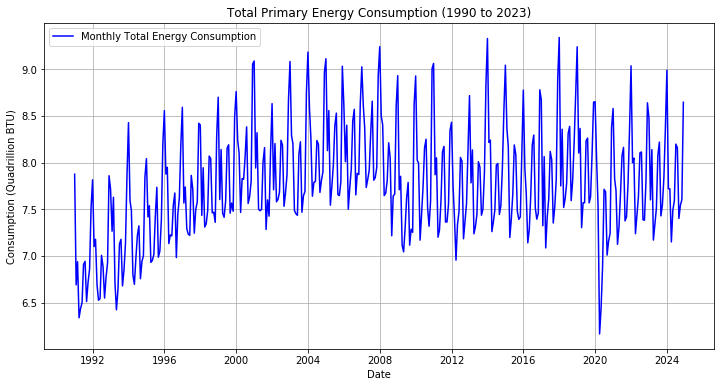

Time series dataset (monthly) consisting of 408 data points


In [43]:
# המרת עמודת הערכים לנומריים
all_data['Value'] = pd.to_numeric(all_data['Value'], errors='coerce')

# יצירת עותק לשמירת הדאטה המקורי
clean_data = all_data.copy()

# המרה למחרוזות לצורך סינון חודש 13
clean_data['YYYYMM'] = clean_data['YYYYMM'].astype(str)

# יצירת year_data עם תאריכים שמסתיימים ב-13 (סיכום שנתי)
year_data = clean_data[clean_data['YYYYMM'].str.endswith('13')].copy()

# ניקוי מהתאריכים הלא תקינים עבור המשתנה data
clean_data = clean_data[~clean_data['YYYYMM'].str.endswith('13')]

# המרת התאריכים לפורמט datetime
clean_data['YYYYMM'] = pd.to_datetime(clean_data['YYYYMM'], format='%Y%m', errors='coerce')

# הסרת ערכים שלא ניתן להמיר לתאריך
clean_data = clean_data.dropna(subset=['YYYYMM'])

# סינון לפי טווח השנים הרצוי
clean_data = clean_data[clean_data['YYYYMM'].dt.year > 1990]
clean_data = clean_data[clean_data['YYYYMM'].dt.year < 2025]

# שינוי שם עמודות
clean_data = clean_data.rename(columns={'YYYYMM': 'Date', 'Value': 'Consumption'}).reset_index(drop=True)

# סינון לפי Column_Order == 12 (Total Primary Energy Consumption)
data = clean_data[clean_data['Column_Order'] == 12]

# בחירת העמודות הרלוונטיות
data = data[['Date', 'Consumption']]

# ויזואליזציה: צריכת אנרגיה חודשית בטוטאל לפי תאריך
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Consumption'], label="Monthly Total Energy Consumption", color='blue')
plt.title("Total Primary Energy Consumption (1990 to 2023)")
plt.xlabel("Date")
plt.ylabel("Consumption (Quadrillion BTU)")
plt.legend()
plt.grid(True)
plt.show()
print(f'Time series dataset (monthly) consisting of {data.shape[0]} data points')

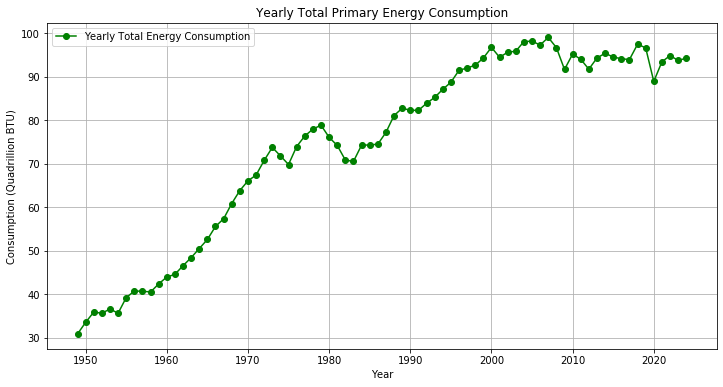

In [44]:
# חילוץ השנה מתוך YYYYMM
year_data['Year'] = year_data['YYYYMM'].str[:4]  # ארבע הספרות הראשונות

# המרת השנה לתאריך של 1 בינואר באותה שנה
year_data['Date'] = pd.to_datetime(year_data['Year'], format='%Y')

# שינוי שם הערך לצריכה, סינון והכנה לגרף
year_data['Consumption'] = pd.to_numeric(year_data['Value'], errors='coerce')
year_data = year_data[year_data['Column_Order'] == 12]
year_data = year_data[['Date', 'Consumption']].dropna()

# גרף 2: צריכת אנרגיה שנתית (מבוססת על חודש 13)
plt.figure(figsize=(12, 6))
plt.plot(year_data['Date'], year_data['Consumption'], marker='o', linestyle='-', label="Yearly Total Energy Consumption", color='green')
plt.title("Yearly Total Primary Energy Consumption")
plt.xlabel("Year")
plt.ylabel("Consumption (Quadrillion BTU)")
plt.legend()
plt.grid(True)
plt.show()

### Identify seasonality, trends, and patterns within the data

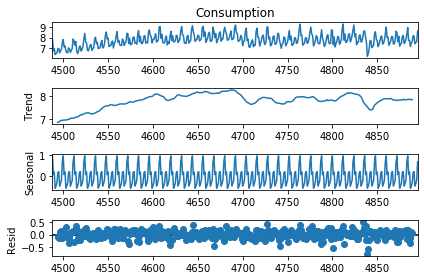

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose

# פירוק הסדרה
decomposition = seasonal_decompose(data['Consumption'], model='additive', period=12)

# ויזואליזציה
decomposition.plot()
plt.show()

#### Seasonality

ADF Statistic: -6.354565438381812
p-value: 2.5616357946213094e-08


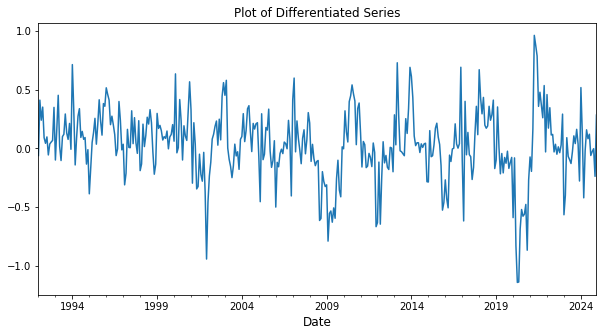

In [46]:
# נסדר את הסדרה בשביל הנוחות
rng = pd.date_range(start = '1991-01-01', end = '2024-12-01', freq='MS')
data.set_index(rng, inplace=True)#change index to dates.

EC = data['Consumption'] # EC = Energy Consumption

#Remove seasonality using diff
EC_year_diff = EC.diff(periods=12)
EC_year_diff = EC_year_diff.dropna() #remove 12 first NaNs

#plot series after removing seasonality
EC_year_diff.plot(figsize=(10,5))
plt.title("Plot of Differentiated Series")
plt.xlabel('Date', fontsize=12);


# בדיקת סטציונריות באמצעות מבחן ADF

from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(EC_year_diff)
print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')

ADF Statistic: -7.722465341469602
p-value: 1.1826331372603752e-11


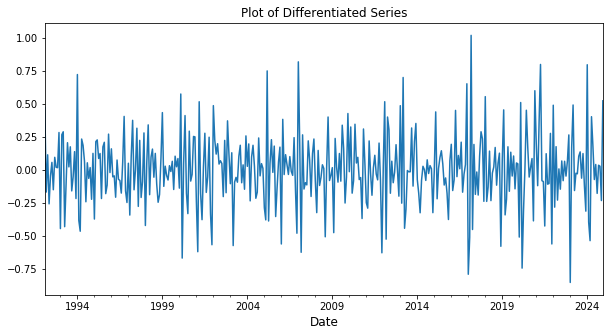

In [47]:
#Remove additional trend
EC_second_diff = EC_year_diff.diff()
EC_second_diff = EC_second_diff.dropna() #remove 12 first NaNs

#plot series after second diff
EC_second_diff.plot(figsize=(10,5))
plt.title("Plot of Differentiated Series")
plt.xlabel('Date', fontsize=12);

adf_test = adfuller(EC_second_diff)
print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')

הגרף אחרי דיפרנציאציה עונתית דומה לרעש לבן, אין בו מגמה ברורה, לכן נוכל להגיד שהסדרה סטציונרית. אין צורך בדיפרנציאציה השנייה

### Additional Visualizations

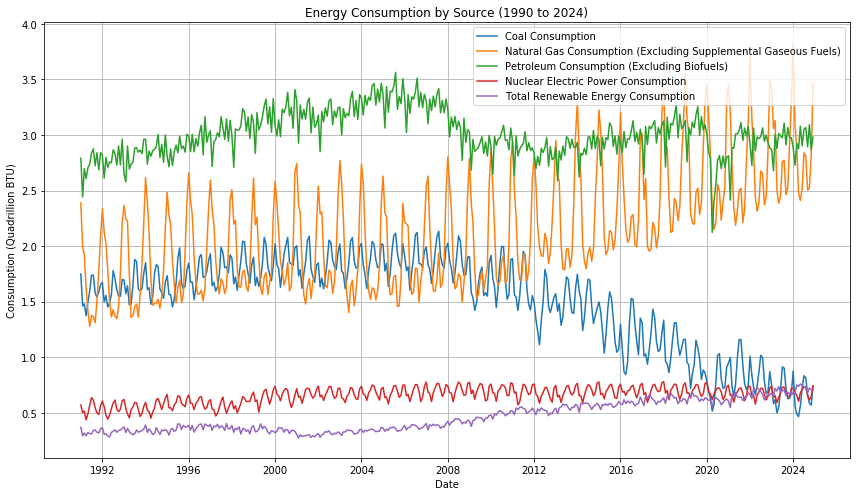

In [48]:
# נרצה להציג את סדרות שמרכיבות את סדרת הצריכה בטוטאל
series_ids = [1, 2, 3, 5, 11]
filtered_data = clean_data[clean_data['Column_Order'].isin(series_ids)].copy()

# ציור הגרף
plt.figure(figsize=(12, 7))

# ציור כל סדרה בנפרד לפי תיאור
for series_id in series_ids:
    series_data = filtered_data[filtered_data['Column_Order'] == series_id]
    label = series_data['Description'].iloc[0]
    plt.plot(series_data['Date'], series_data['Consumption'], label=label)

plt.title("Energy Consumption by Source (1990 to 2024)")
plt.xlabel("Date")
plt.ylabel("Consumption (Quadrillion BTU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
import plotly.express as px

# רשימת התיאורים שמרכיבים את הסדרה הכוללת
components = [
    'Coal Consumption',
    'Natural Gas Consumption (Excluding Supplemental Gaseous Fuels)',
    'Petroleum Consumption (Excluding Biofuels)',
    'Nuclear Electric Power Consumption',
    'Total Renewable Energy Consumption'
]

# סינון הנתונים לרכיבים האלה בלבד
component_data = clean_data[clean_data['Description'].isin(components)].copy()

# חישוב סך הצריכה לכל רכיב
summary = component_data.groupby('Description')['Consumption'].sum().reset_index()

# Tree Map
fig = px.treemap(summary,
                 path=['Description'],
                 values='Consumption',
                 title='Total Primary Energy Consumption Breakdown',
                 color='Consumption',
                 color_continuous_scale='Blues'  # שינוי לפלטת צבעים
)
fig.update_traces(textfont_size=20)

fig.update_layout(
    width=1200,
    height=600
)

fig.show()

## Part 2 - Model Fitting

In [50]:
# Split into training/testing sets (80% training, 20% testing)
train_size = int(len(EC) * 0.8)
EC_train = EC[:train_size]
EC_test = EC[train_size:]

# Calculate the split index
split_index = int(len(EC) * 0.8)

# Print shapes of splits
print(f"Train Data {EC_train.shape[0]} Points")
print(f"Test Data {EC_test.shape[0]} Points")


Train Data 326 Points
Test Data 82 Points


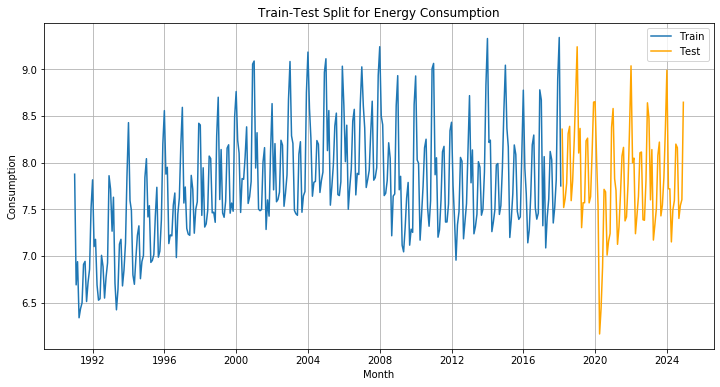

In [51]:
import numpy as np

# Plot the train-test split
plt.figure(figsize=(12, 6))
plt.plot(EC_train.index, EC_train, label='Train')
plt.plot(EC_test.index, EC_test, label='Test', color='orange')
plt.xlabel('Month')
plt.ylabel('Consumption')
plt.title('Train-Test Split for Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()

In [52]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Function to calculate evaluation metrics
def calculate_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

# Function to plot forecasts
def plot_forecast(train, test, forecast, model_name):
    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train, label='Training Data')
    plt.plot(test.index, test, label='Actual Test Data')
    plt.plot(test.index, forecast, label=f'{model_name} Forecast')
    plt.title(f'{model_name} Forecast vs Actual')
    plt.xlabel('Date')
    plt.ylabel('Consumption (Quadrillion BTU)')
    plt.legend()
    plt.grid(True)
    plt.show()

### SARIMA

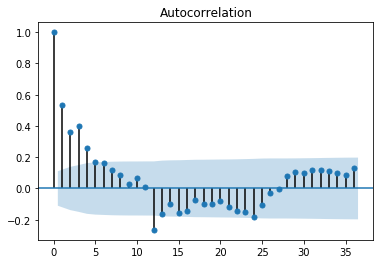

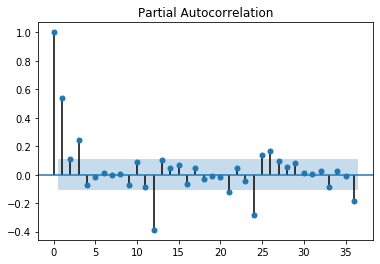

In [53]:
from statsmodels.graphics import tsaplots
from statsmodels.tsa.statespace.sarimax import SARIMAX

#Remove seasonality using diff
EC_train_year_diff = EC_train.diff(periods=12).dropna()

#plot autocorrelation for new series
tsaplots.plot_acf(EC_train_year_diff,lags=36);
tsaplots.plot_pacf(EC_train_year_diff,lags=36);

נשים לב
* בכל המודלים D=1 עשינו דיפרנציאציה עונתית לכן
* בכל המודלים d=0 בחרנו לא לעשות דיפרנציאציה רגילה נוספת לכן

1.  the ACFs decay to zero after lag 3, the ACF of order 12,24 are different than ziro
2.  the first and the third PACFs are different than zero -> consider AR(1)
3.  the PACFs of order 12, 24 are also different than zero. ->  ARנבדוק רכיב עונתי

מודלים שיכולים להתאים
1. מודל פשוט SARIMA $(p,0,0)(0,1,0)_{12}$    p=1,3
2. נבדוק גם רכיבים עונתיים  SARIMA $(p,0,0)(P,1,Q)_{12}$     p=1,  P=0,1, Q=0,1  
3. נבדוק רכיב MA(1)

הערה:
לא נציג את בדיקת המודלים הפשוטים ביותר שהצענו בסעיף הראשון, הם פשוטים מידי ולא לוקחים בחשבון רכיבים עונתיים שבבירור קיימים כי הלגים מסדר גבוה שונים מ0.

#### נבדוק מודלים אפשריים


In [54]:
# P=1, p=1
model_sarima_p1P1 = SARIMAX(EC_train, order=(1, 0, 0), seasonal_order=(1, 1, 0,12))
model_fit_sarima_p1P1 = model_sarima_p1P1.fit(disp=False)
print(model_fit_sarima_p1P1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        Consumption   No. Observations:                  326
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood                  39.358
Date:                            Sun, 06 Apr 2025   AIC                            -72.715
Time:                                    21:01:01   BIC                            -61.467
Sample:                                01-01-1991   HQIC                           -68.221
                                     - 02-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6033      0.040     15.010      0.000       0.524       0.682
ar.S.L12      -0.3843      0.050   

In [55]:
# P=1, p=1, q=1, Q=1
model_sarima_p1P1q1Q1 = SARIMAX(EC_train, order=(1, 0, 1), seasonal_order=(1, 1, 1,12))
model_fit_sarima_p1P1q1Q1 = model_sarima_p1P1q1Q1.fit(disp=False)
print(model_fit_sarima_p1P1q1Q1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        Consumption   No. Observations:                  326
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                  83.622
Date:                            Sun, 06 Apr 2025   AIC                           -157.244
Time:                                    21:01:02   BIC                           -138.497
Sample:                                01-01-1991   HQIC                          -149.753
                                     - 02-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9699      0.018     53.897      0.000       0.935       1.005
ma.L1         -0.5403      0.050   

In [56]:
# P=0, p=1, q=1, Q=1
model_sarima_p1q1Q1 = SARIMAX(EC_train, order=(1, 0, 1), seasonal_order=(0, 1, 1,12))
model_fit_sarima_p1q1Q1 = model_sarima_p1q1Q1.fit(disp=False)
print(model_fit_sarima_p1q1Q1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        Consumption   No. Observations:                  326
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood                  83.208
Date:                            Sun, 06 Apr 2025   AIC                           -158.416
Time:                                    21:01:03   BIC                           -143.418
Sample:                                01-01-1991   HQIC                          -152.423
                                     - 02-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9705      0.017     55.531      0.000       0.936       1.005
ma.L1         -0.5399      0.050   

In [ ]:
# Plot diagnostics (robust to Timestamp index issues in some environments)
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

resid = pd.Series(model_fit_sarima_p1q1Q1.resid).dropna().astype(float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals over time
axes[0, 0].plot(resid.index, resid.values)
axes[0, 0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Standardized residuals')

# Histogram
axes[0, 1].hist(resid.values, bins=30, edgecolor='k', alpha=0.75)
axes[0, 1].set_title('Histogram')

# Q-Q plot
stats.probplot(resid.values, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q')

# ACF
plot_acf(resid.values, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('Correlogram')

plt.tight_layout()
plt.show()

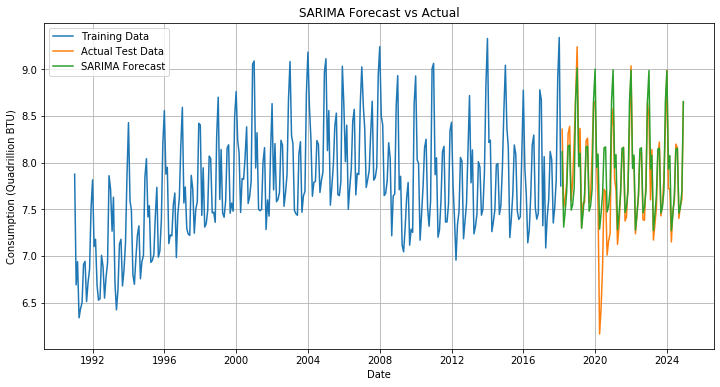

In [59]:
# חיזוי
forecast_obj = model_fit_sarima_p1q1Q1.get_forecast(steps=len(EC_test))
SARIMA_forecast = forecast_obj.predicted_mean

# הצגת החיזוי והשווה לטסט
plot_forecast(EC_train, EC_test, SARIMA_forecast, 'SARIMA')

In [60]:
metrics = calculate_metrics(EC_test, SARIMA_forecast)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

MSE: 0.0803
RMSE: 0.2833
MAE: 0.1874
MAPE: 2.4897


### Exponential Smoothing (Holt Winters)

C:\Users\ofekf\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:342: FutureWarning:

The 'freq' argument in Timestamp is deprecated and will be removed in a future version.



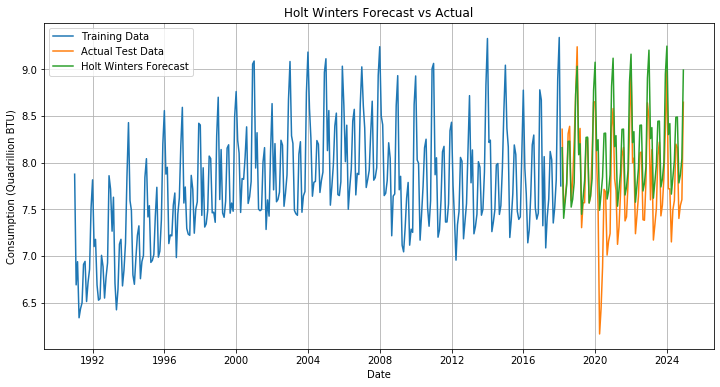

In [61]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

SES = ExponentialSmoothing(EC_train, seasonal_periods=12, trend='add', seasonal='add')
ses_fit = SES.fit()
HW_forecast = ses_fit.forecast(len(EC_test))
plot_forecast(EC_train, EC_test, HW_forecast, 'Holt Winters')

In [62]:
metrics = calculate_metrics(EC_test, HW_forecast)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

MSE: 0.1793
RMSE: 0.4235
MAE: 0.3435
MAPE: 4.5319


### Prophet

In [63]:
df_prophet = EC_train.reset_index().copy() #resetting the index here
df_prophet = df_prophet.rename(columns={'Consumption': 'y', 'index': 'ds'}) # renaming
df_prophet = df_prophet[['ds','y']]
df_prophet.head()

,ds,y
0,1991-01-01,7.874721
1,1991-02-01,6.689547
2,1991-03-01,6.937734
3,1991-04-01,6.336924
4,1991-05-01,6.434275


In [68]:
pip install --upgrade packaging

  Attempting uninstall: packaging
    Found existing installation: packaging 20.1
    Uninstalling packaging-20.1:
      Successfully uninstalled packaging-20.1
Note: you may need to restart the kernel to use updated packages.


ERROR: pytest-astropy 0.8.0 requires pytest-cov>=2.0, which is not installed.
ERROR: pytest-astropy 0.8.0 requires pytest-filter-subpackage>=0.1, which is not installed.


In [ ]:
from prophet import Prophet

# Initialize Prophet model (disabling daily and weekly seasonality for monthly data)
prophet_model = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True)
prophet_model.fit(df_prophet)


In [ ]:
# Create a future DataFrame extending by the number of test periods
future = prophet_model.make_future_dataframe(periods=len(EC_test), freq='MS')
forecast = prophet_model.predict(future)

In [ ]:
# Visualize the forecast components (trend, yearly seasonality)
from prophet.plot import plot_components
fig_comp = plot_components(prophet_model, forecast, figsize=(10, 5))
plt.tight_layout()
plt.show()

In [ ]:
prophet_forecast = forecast.set_index('ds').loc[EC_test.index, 'yhat']

plot_forecast(EC_train, EC_test, prophet_forecast, 'Prophet')

In [ ]:
prophet_forecast

In [ ]:
metrics = calculate_metrics(EC_test, prophet_forecast)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

### Regression with Fourier terms

#### Linear trend

In [ ]:
# נקח את הדאטה שהשתמשנו בו בחלק הראשון ונסדר שיתאים למשימה
EC_data = data.copy().reset_index(drop=True)

# Calculate the split index
split_index = int(len(EC_data) * 0.8)

# Split the data
train_df = EC_data.iloc[:split_index]
test_df = EC_data.iloc[split_index:]

print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)

In [ ]:
from sklearn.linear_model import LinearRegression

# Ensure EC_data exists and has a numeric index for trend modeling
EC_data = data.copy().reset_index(drop=True)

X_linear = np.array([np.ones(len(EC_data)), EC_data.index.values]).T
train_X_linear = X_linear[:split_index]
train_y_linear = train_df['Consumption']
test_X_linear = X_linear[split_index:]
test_y_linear = test_df['Consumption']

linear_model = LinearRegression()
linear_model.fit(train_X_linear, train_y_linear)
y_pred = linear_model.predict(test_X_linear)

plt.figure(figsize=(7, 5))
plt.plot(test_y_linear.index, y_pred, label="Linear")
plt.plot(test_y_linear, label='True', color='orange')
plt.xlabel('Month in the time series')
plt.ylabel('Consumption')
plt.title("Linear Regression")
plt.legend()
plt.show()

#### linear trend + seasonality

In [ ]:
# הגדרת תדרים עונתיים (פורייה)
lambdas = 2 * np.pi * np.arange(1, 7) / 12
X_seasonality = np.array([
    np.concatenate([np.cos(lambdas * t), np.sin(lambdas * t)])
    for t in EC_data.index.values
])

# יצירת משתני מגמה + עונתיות
X_linear = np.array([np.ones(len(EC_data)), EC_data.index.values]).T
X_linear_seasonality = np.concatenate([X_linear, X_seasonality], axis=1)

# חלוקה לסט אימון ומבחן לפי אינדקסים
train_X = X_linear_seasonality[:split_index]
train_y = EC_data['Consumption'][:split_index]
train_dates = EC_data['Date'][:split_index]

test_X = X_linear_seasonality[split_index:]
test_y = EC_data['Consumption'][split_index:]
test_dates = EC_data['Date'][split_index:]

# התאמת המודל
model_seasonality = LinearRegression()
model_seasonality.fit(train_X, train_y)

# חיזוי
y_pred = model_seasonality.predict(test_X)

# הפיכת התחזיות ל־Series עם אינדקס תאריכים
y_pred_linear_seasonality = pd.Series(y_pred, index=test_dates)
train_y_series = pd.Series(train_y.values, index=train_dates)
test_y_series = pd.Series(test_y.values, index=test_dates)

# plot
plot_forecast(train_y_series, test_y_series, y_pred_linear_seasonality, 'Linear Regression with Seasonality')


In [ ]:
metrics = calculate_metrics(test_y_linear_seasonality, y_pred)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

#### linear trend + seasonality + AR(1)

In [ ]:
# בניית משתני AR + עונתיות
X_AR = np.concatenate([
    X_linear_seasonality[1:],  # מגמה + עונתיות
    EC_data['Consumption'].values[:-1].reshape(-1, 1)  # y_{t-1}
], axis=1)

# תיארוך נכון של הנתונים
dates = EC_data['Date'][1:]  # בגלל שהסרנו את התצפית הראשונה ב־X_AR

# חלוקה לסט אימון ומבחן
train_X_AR = X_AR[:split_index - 1]
train_y_AR = EC_data['Consumption'][1:split_index]
train_dates_AR = dates[:split_index - 1]

test_X_AR = X_AR[split_index - 1:]
test_y_AR = EC_data['Consumption'][split_index:]
test_dates_AR = dates[split_index - 1:]

# איפוס ערך y_{t-1} בתחזית
test_X_AR[1:, -1] = np.nan  # נעדכן ערך זה בכל צעד לפי התחזית

# התאמת המודל
model_AR = LinearRegression()
model_AR.fit(train_X_AR, train_y_AR)

# חיזוי ריקורסיבי עם עדכון AR
y_preds = []
x = test_X_AR[0].copy().reshape(1, -1)

for i in range(len(test_y_AR)):
    pred = model_AR.predict(x)[0]
    y_preds.append(pred)

    if i + 1 < len(test_y_AR):
        x = test_X_AR[i+1].copy().reshape(1, -1)
        x[0, -1] = pred  # עדכון AR לפי תחזית קודמת

# הפיכת נתונים ל־Series עם אינדקס תאריכים
y_pred_AR = pd.Series(y_preds, index=test_dates_AR)
train_y_AR_series = pd.Series(train_y_AR.values, index=train_dates_AR)
test_y_AR_series = pd.Series(test_y_AR.values, index=test_dates_AR)

# ציור גרף עם תאריכים
plot_forecast(train_y_AR_series, test_y_AR_series, y_pred_AR, 'Linear Regression with Seasonality + AR')


In [ ]:
metrics = calculate_metrics(test_y_AR.values, y_pred_AR.values)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

### LSTM

#### אימון הרשת

Using device: cpu
Epoch [10/200], Train Loss: 0.0189, Val Loss: 0.0193
Epoch [20/200], Train Loss: 0.0153, Val Loss: 0.0154
Epoch [30/200], Train Loss: 0.0126, Val Loss: 0.0139
Epoch [40/200], Train Loss: 0.0101, Val Loss: 0.0120
Epoch [50/200], Train Loss: 0.0107, Val Loss: 0.0137
Epoch 00058: reducing learning rate of group 0 to 5.0000e-04.
Epoch [60/200], Train Loss: 0.0105, Val Loss: 0.0120
Epoch [70/200], Train Loss: 0.0084, Val Loss: 0.0111
Epoch 00080: reducing learning rate of group 0 to 2.5000e-04.
Epoch [80/200], Train Loss: 0.0088, Val Loss: 0.0108
Epoch [90/200], Train Loss: 0.0090, Val Loss: 0.0111
Epoch 00093: reducing learning rate of group 0 to 1.2500e-04.
Epoch [100/200], Train Loss: 0.0091, Val Loss: 0.0108
Early stopping at epoch 102


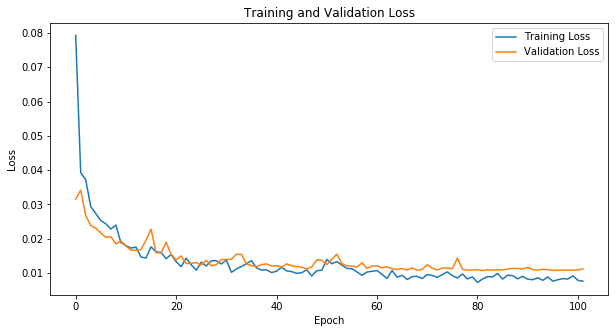

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import math

# Preprocessing the data
scaler = MinMaxScaler(feature_range=(0, 1))
EC_train_scaled = scaler.fit_transform(EC_train.values.reshape(-1, 1))
EC_test_scaled = scaler.transform(EC_test.values.reshape(-1, 1))

# Add time-based features
def add_time_features(dates):
    # Create dataframe with date-based features
    df_features = pd.DataFrame(index=dates)

    # Add cyclical encoding for month (captures seasonality better than linear values)
    df_features['month_sin'] = np.sin(2 * np.pi * dates.month / 12)
    df_features['month_cos'] = np.cos(2 * np.pi * dates.month / 12)

    # Add cyclical encoding for day of year
    day_of_year = dates.dayofyear
    df_features['day_of_year_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_features['day_of_year_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Add trend feature (time progression)
    df_features['time_idx'] = np.arange(len(dates)) / len(dates)

    # Add year as a normalized feature
    min_year = dates.year.min()
    max_year = dates.year.max()
    if max_year > min_year:  # Avoid division by zero
        df_features['year_norm'] = (dates.year - min_year) / (max_year - min_year)
    else:
        df_features['year_norm'] = 0

    return df_features

# Create additional features
train_features = add_time_features(EC_train.index)
test_features = add_time_features(EC_test.index)

# Scale these features
features_scaler = MinMaxScaler(feature_range=(0, 1))
train_features_scaled = features_scaler.fit_transform(train_features)
test_features_scaled = features_scaler.transform(test_features)

# Create sequences with additional features
def create_sequences_with_features(data, features, seq_length):
    xs, ys, feat = [], [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        # Get features for the target time point
        f = features[i+seq_length]
        xs.append(x)
        ys.append(y)
        feat.append(f)
    return np.array(xs), np.array(ys), np.array(feat)

seq_length = 24  # Use 24 months history for better pattern capture
X_train, y_train, feat_train = create_sequences_with_features(
    EC_train_scaled, train_features_scaled, seq_length
)

# Combine last 24 months from training with test set to build full context
EC_test_input = np.concatenate((EC_train_scaled[-seq_length:], EC_test_scaled))
test_features_input = np.concatenate((train_features_scaled[-seq_length:], test_features_scaled))

# Build sequences using combined context
X_test_full, y_test_full, feat_test_full = create_sequences_with_features(
    EC_test_input, test_features_input, seq_length
)

# Keep only the sequences that correspond to the test set
X_test = X_test_full[:len(EC_test_scaled)]
y_test = y_test_full[:len(EC_test_scaled)]
feat_test = feat_test_full[:len(EC_test_scaled)]


# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).reshape(-1, seq_length, 1)
y_train = torch.tensor(y_train, dtype=torch.float32)
feat_train = torch.tensor(feat_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32).reshape(-1, seq_length, 1)
y_test = torch.tensor(y_test, dtype=torch.float32)
feat_test = torch.tensor(feat_test, dtype=torch.float32)

# Enhanced Dataset class that includes the additional features
class EnhancedTimeSeriesDataset(Dataset):
    def __init__(self, X, y, features):
        self.X = X
        self.y = y
        self.features = features

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.features[idx], self.y[idx]

train_dataset = EnhancedTimeSeriesDataset(X_train, y_train, feat_train)
test_dataset = EnhancedTimeSeriesDataset(X_test, y_test, feat_test)

batch_size = 32  # Increased batch size for better gradient estimation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Custom loss function that combines MSE with Huber loss for robustness against outliers
class CombinedLoss(nn.Module):
    def __init__(self, delta=1.0):
        super(CombinedLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.huber = nn.HuberLoss(delta=delta)

    def forward(self, y_pred, y_true):
        mse_loss = self.mse(y_pred, y_true)
        huber_loss = self.huber(y_pred, y_true)
        # Weighted combination of the losses
        return 0.7 * mse_loss + 0.3 * huber_loss

# Advanced Bidirectional LSTM Model with feature integration and attention
class EnhancedBiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, feature_size, output_size, dropout=0.3):
        super(EnhancedBiLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Bidirectional LSTM layers
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        # Layer normalization for better training stability
        self.layer_norm = nn.LayerNorm(hidden_size * 2)  # * 2 because bidirectional

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1),
            nn.Softmax(dim=1)
        )

        # Feature integration layer
        self.feature_layer = nn.Linear(feature_size, hidden_size)

        # Combine LSTM output with features
        self.combine_layer = nn.Linear(hidden_size * 2 + hidden_size, hidden_size)

        # Output layer with dropout for regularization
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, features):
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)  # * 2 for bidirectional
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate through LSTM
        lstm_out, _ = self.lstm(x, (h0, c0))

        # Apply layer normalization
        lstm_out = self.layer_norm(lstm_out)

        # Apply attention
        attention_weights = self.attention(lstm_out)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)

        # Process additional features
        feature_vector = torch.relu(self.feature_layer(features))

        # Combine LSTM output with features
        combined = torch.cat((context_vector, feature_vector), dim=1)
        combined = torch.relu(self.combine_layer(combined))

        # Apply dropout and final layer
        combined = self.dropout(combined)
        output = self.fc(combined)

        return output

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Model parameters
input_size = 1  # univariate time series
hidden_size = 64  # increased hidden size for more capacity
num_layers = 2  # multiple layers for hierarchical feature learning
feature_size = feat_train.shape[1]  # number of additional features
output_size = 1  # predicting one value

# Initialize model
model = EnhancedBiLSTMModel(
    input_size,
    hidden_size,
    num_layers,
    feature_size,
    output_size,
    dropout=0.3
)
model.to(device)

# Loss and optimizer
criterion = CombinedLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Added weight decay for regularization

# Learning rate scheduler to reduce lr when training plateaus
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10,
    verbose=True
)

# Early stopping parameters
best_val_loss = float('inf')
patience = 20
patience_counter = 0

# Training Loop
num_epochs = 200
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for batch_X, batch_feat, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_feat = batch_feat.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X, batch_feat)
        loss = criterion(outputs, batch_y)
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_feat, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_feat = batch_feat.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X, batch_feat)
            val_loss += criterion(outputs, batch_y).item() * batch_X.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    # Update learning rate
    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_lstm_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load the best model
model.load_state_dict(torch.load('best_lstm_model.pth'))

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


#### תחזית

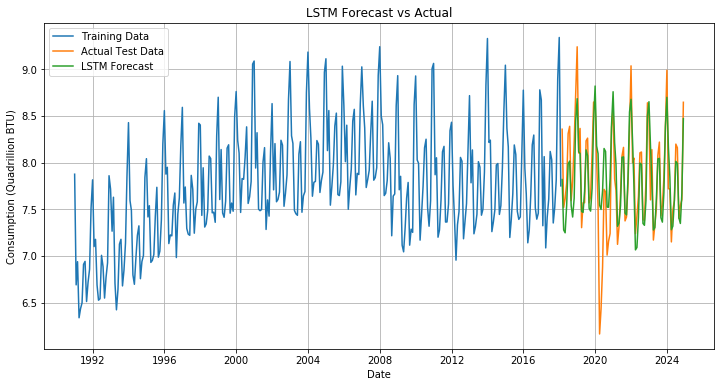

In [36]:
# Evaluation
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for batch_X, batch_feat, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_feat = batch_feat.to(device)
        batch_y = batch_y.to(device)
        outputs = model(batch_X, batch_feat)
        predictions.append(outputs.cpu().numpy())
        actuals.append(batch_y.cpu().numpy())

predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# Inverse transform predictions to original scale
predictions_orig = scaler.inverse_transform(predictions)
actuals_orig = scaler.inverse_transform(actuals)

# Adjust the test dates to account for the sequence length offset
test_dates = EC_test.index[seq_length:]

# plot forecast
LSTM_forecast = pd.Series(predictions_orig.flatten(), index=EC_test.index)
actual_test_series = pd.Series(actuals_orig.flatten(), index=EC_test.index)

plot_forecast(EC_train, actual_test_series, LSTM_forecast, 'LSTM')

In [37]:
metrics = calculate_metrics(actual_test_series, LSTM_forecast)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

MSE: 0.1132
RMSE: 0.3365
MAE: 0.2458
MAPE: 3.2296


### השוואת תוצאות

In [ ]:
plt.figure(figsize=(12, 6))

# Plot actual test data
plt.plot(EC_test.index, EC_test.values, label='Actual', color='orange', linewidth=2)

# Plot forecasts only if they are defined in the current run
if 'SARIMA_forecast' in globals():
    plt.plot(SARIMA_forecast.index, SARIMA_forecast.values, label='SARIMA', linestyle='--')

if 'HW_forecast' in globals():
    plt.plot(HW_forecast.index, HW_forecast.values, label='Holt-Winters', linestyle='--')

if 'prophet_forecast' in globals():
    plt.plot(prophet_forecast.index, prophet_forecast.values, label='Prophet', linestyle='--')

if 'y_pred_AR' in globals():
    plt.plot(y_pred_AR.index, y_pred_AR.values, label='Linear + Seasonality + AR', linestyle='--')

if 'LSTM_forecast' in globals():
    plt.plot(LSTM_forecast.index, LSTM_forecast.values, label='LSTM', linestyle='--')

# Styling
plt.title("Forecast Comparison on Test Set")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Quadrillion BTU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Part 3 - Incorporating an Exogenous Variable

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load temperature data as exogenous variable
temp_data = pd.read_csv('/temp.csv')

# Convert date format to proper datetime
temp_data['Date'] = pd.to_datetime(temp_data['Date'].astype(str), format='%Y%m')

# Set date as index
temp_data.set_index('Date', inplace=True)

# Rename temperature column to use Celsius values (c_v)
temp_data.rename(columns={'c_v': 'Temperature'}, inplace=True)


In [ ]:
print("Temperature Data Overview:")
print(temp_data.head())

# Plot the temperature data
plt.figure(figsize=(12, 6))
plt.plot(temp_data.index, temp_data['Temperature'], label='Mean Monthly Temperature')
plt.title('US Average Monthly Temperature (1985-2024)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Join temperature with energy consumption data
# First ensure the indices are aligned
EC_with_temp = pd.DataFrame(EC)
EC_with_temp = EC_with_temp.join(temp_data[['Temperature']], how='left')

# Check for missing temperature values
missing_temps = EC_with_temp['Temperature'].isna().sum()
print(f"Missing temperature values: {missing_temps}")

# Handle missing values if any
if missing_temps > 0:
    # Fill with interpolation (more sophisticated methods could be used)
    EC_with_temp['Temperature'].interpolate(method='time', inplace=True)
    print(f"After interpolation, missing temperature values: {EC_with_temp['Temperature'].isna().sum()}")
EC_with_temp.head()

In [ ]:
# Plot dual axis to show both series
plt.figure(figsize=(16, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot energy consumption on first axis
ax1.plot(EC_with_temp.index, EC_with_temp['Consumption'], 'b-', label='Energy Consumption')
ax1.set_ylabel('Energy Consumption (Quadrillion BTU)', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

# Plot temperature on second axis
ax2.plot(EC_with_temp.index, EC_with_temp['Temperature'], 'r-', label='Temperature (°C)')
ax2.set_ylabel('Temperature (°C)', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Energy Consumption vs Temperature (1991-2024)', fontsize=14)
plt.grid(True)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

# Create a scatter plot to better visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=EC_with_temp, x='Temperature', y='Consumption')
plt.title('Relationship Between Temperature and Energy Consumption')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Consumption (Quadrillion BTU)')
plt.grid(True)
plt.show()


In [ ]:
# Calculate correlation
correlation = EC_with_temp['Consumption'].corr(EC_with_temp['Temperature'])
print(f"Overall correlation between Energy Consumption and Temperature: {correlation:.4f}")

EC_with_temp['Temp_Range'] = pd.cut(
    EC_with_temp['Temperature'],
    bins=[-20, 0, 10, 20, 30],
    labels=['Very Cold', 'Cold', 'Moderate', 'Hot']
)
print("\nCorrelation by Temperature Range:")
for temp_range in EC_with_temp['Temp_Range'].unique():
    if pd.notnull(temp_range):  # Skip NaN values
        subset = EC_with_temp[EC_with_temp['Temp_Range'] == temp_range]
        if len(subset) > 5:  # Ensure enough data points
            corr, p_value = pearsonr(subset['Temperature'], subset['Consumption'])
            print(f"{temp_range}: {corr:.4f} (p-value: {p_value:.4f}, n={len(subset)})")


In [ ]:
# Add month information for seasonal analysis
EC_with_temp['Month'] = EC_with_temp.index.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

EC_with_temp['Season'] = EC_with_temp['Month'].apply(get_season)

# Visualize energy consumption by month
plt.figure(figsize=(12, 6))
sns.boxplot(data=EC_with_temp, x='Month', y='Consumption')
plt.title('Monthly Distribution of Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Energy Consumption (Quadrillion BTU)')
plt.show()


In [ ]:
#  Heating and Cooling Degree Days (HDD and CDD)
ref_temp_celsius = 18.0
EC_with_temp['HDD'] = np.maximum(0, ref_temp_celsius - EC_with_temp['Temperature'])
EC_with_temp['CDD'] = np.maximum(0, EC_with_temp['Temperature'] - ref_temp_celsius)
# Create filtered versions (set zeros to NaN so that only active days are considered)
EC_with_temp['HDD_filtered'] = EC_with_temp['HDD'].replace(0, np.nan)
EC_with_temp['CDD_filtered'] = EC_with_temp['CDD'].replace(0, np.nan)
EC_with_temp.drop(['HDD', 'CDD'], axis=1, inplace=True)

# Comfort Zone Indicator: 1 if Temperature is within ±4°C of ref_temp_celsius
comfort_range = 4.0
EC_with_temp['Comfort_Zone'] = (
    (EC_with_temp['Temperature'] > (ref_temp_celsius - comfort_range)) &
    (EC_with_temp['Temperature'] < (ref_temp_celsius + comfort_range))
).astype(int)

# Extreme Temperature Indicator: Is_Cold (for very low temperatures)
cold_threshold = 0  # Celsius
EC_with_temp['Is_Cold'] = (EC_with_temp['Temperature'] < cold_threshold).astype(int)


In [ ]:
# Visualize relationship between energy consumption and created features
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Relationship between Energy Consumption and Temperature Features', fontsize=16)

# HDD filtered vs Consumption
sns.scatterplot(data=EC_with_temp.dropna(subset=['HDD_filtered']),
               x='HDD_filtered', y='Consumption', ax=axes[0, 0])
axes[0, 0].set_title('Filtered HDD vs Consumption')
axes[0, 0].set_xlabel('HDD (zeros removed)')
axes[0, 0].set_ylabel('Energy Consumption (Quadrillion BTU)')

# CDD filtered vs Consumption
sns.scatterplot(data=EC_with_temp.dropna(subset=['CDD_filtered']),
               x='CDD_filtered', y='Consumption', ax=axes[0, 1])
axes[0, 1].set_title('Filtered CDD vs Consumption')
axes[0, 1].set_xlabel('CDD (zeros removed)')
axes[0, 1].set_ylabel('Energy Consumption (Quadrillion BTU)')

# Comfort Zone vs Consumption
sns.boxplot(data=EC_with_temp, x='Comfort_Zone', y='Consumption', ax=axes[1, 0])
axes[1, 0].set_title('Comfort Zone vs Consumption')
axes[1, 0].set_xlabel('In Comfort Zone (18°C ± 4°C)')
axes[1, 0].set_ylabel('Energy Consumption (Quadrillion BTU)')

# Piecewise Temperature Effects
sns.lineplot(data=EC_with_temp, x='Temperature', y='Consumption',
            hue='Temp_Range', ax=axes[1, 1])
axes[1, 1].set_title('Piecewise Temperature Effects')
axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Energy Consumption (Quadrillion BTU)')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()



In [ ]:
features_for_heatmap = [
    'Consumption',
    'Temperature',
    'HDD_filtered',
    'CDD_filtered',
    'Comfort_Zone',
    'Is_Cold',

    # Optionally, add 'HDD_Winter_filtered' if desired.
]
corr_matrix = EC_with_temp[features_for_heatmap].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Features')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Split data into train and test sets
train_size = int(len(EC) * 0.8)
train_data = EC_with_temp.iloc[:train_size].copy()
test_data = EC_with_temp.iloc[train_size:].copy()

# Fit SARIMA model with no exogenous variables
sarima_model = SARIMAX(
    train_data['Consumption'],
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False
)
sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary())


# Forecast and compute evaluation metrics
sarima_forecast = sarima_results.forecast(steps=len(test_data))
sarima_mae = mean_absolute_error(test_data['Consumption'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_data['Consumption'], sarima_forecast))
sarima_mape = np.mean(np.abs((test_data['Consumption'].values - sarima_forecast) / test_data['Consumption'].values)) * 100
sarima_r2 = r2_score(test_data['Consumption'], sarima_forecast)

print("\nBaseline SARIMA Evaluation Metrics:")
print(f"MAE: {sarima_mae:.4f}")
print(f"RMSE: {sarima_rmse:.4f}")
print(f"MAPE: {sarima_mape:.2f}%")
print(f"R²: {sarima_r2:.4f}")


In [ ]:
# Prepare exogenous variable: only Temperature.
basic_exog = train_data[['Temperature']].copy()
basic_test_exog = test_data[['Temperature']].copy()

# Fit SARIMAX model with Temperature as the only exogenous variable.
basic_sarimax_model = SARIMAX(
    train_data['Consumption'],
    exog=basic_exog,
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False
)
basic_sarimax_results = basic_sarimax_model.fit(disp=False)
print("SARIMAX Model with Only Temperature:")
print(basic_sarimax_results.summary())

# Forecast and compute evaluation metrics for the basic exogenous model.
basic_sarimax_forecast = basic_sarimax_results.forecast(steps=len(test_data), exog=basic_test_exog)
basic_mae = mean_absolute_error(test_data['Consumption'], basic_sarimax_forecast)
basic_rmse = np.sqrt(mean_squared_error(test_data['Consumption'], basic_sarimax_forecast))
basic_mape = np.mean(np.abs((test_data['Consumption'].values - basic_sarimax_forecast) / test_data['Consumption'].values)) * 100
basic_r2 = r2_score(test_data['Consumption'], basic_sarimax_forecast)

print("\nSARIMAX (Basic) Evaluation Metrics:")
print(f"MAE: {basic_mae:.4f}")
print(f"RMSE: {basic_rmse:.4f}")
print(f"MAPE: {basic_mape:.2f}%")
print(f"R²: {basic_r2:.4f}")



In [ ]:
# Define the streamlined set of features.
selected_features = ['Temperature', 'HDD_filtered','Is_Cold','Comfort_Zone']

# Prepare exogenous variables using the selected features.
train_exog = train_data[selected_features].copy()
test_exog = test_data[selected_features].copy()
train_exog.head()
# Fill any missing values in the filtered features with the median from the training set.
for feature in selected_features:
    if '_filtered' in feature:
        median_value = train_exog[feature].dropna().median()
        train_exog[feature] = train_exog[feature].fillna(median_value)
        test_exog[feature] = test_exog[feature].fillna(median_value)

# Fit SARIMAX with advanced temperature features.
sarimax_model = SARIMAX(
    train_data['Consumption'],
    exog=train_exog,
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False
)
sarimax_results = sarimax_model.fit(disp=False, maxiter=1000,)
print("SARIMAX Model with Advanced Temperature Features:")
print(sarimax_results.summary())

# Forecast on test data using advanced exogenous variables.
sarimax_forecast = sarimax_results.forecast(steps=len(test_data), exog=test_exog)

# Compute evaluation metrics for the advanced model.
sarimax_mae = mean_absolute_error(test_data['Consumption'], sarimax_forecast)
sarimax_rmse = np.sqrt(mean_squared_error(test_data['Consumption'], sarimax_forecast))
sarimax_mape = np.mean(np.abs((test_data['Consumption'].values - sarimax_forecast) / test_data['Consumption'].values)) * 100
sarimax_r2 = r2_score(test_data['Consumption'], sarimax_forecast)

print("\nSARIMAX (Advanced) Evaluation Metrics:")
print(f"MAE: {sarimax_mae:.4f}")
print(f"RMSE: {sarimax_rmse:.4f}")
print(f"MAPE: {sarimax_mape:.2f}%")
print(f"R²: {sarimax_r2:.4f}")


In [ ]:

# Print a summary of evaluation metrics for all three models.
print("\nModel Comparison - Evaluation Metrics:")
print(f"{'Model':<25} {'MAE':<8} {'RMSE':<8} {'MAPE':<8} {'R²':<8}")
print(f"{'SARIMA (No temp)':<25} {sarima_mae:.4f}  {sarima_rmse:.4f}  {sarima_mape:.2f}%  {sarima_r2:.4f}")
print(f"{'SARIMAX (Basic temp)':<25} {basic_mae:.4f}  {basic_rmse:.4f}  {basic_mape:.2f}%  {basic_r2:.4f}")
print(f"{'SARIMAX (Advanced temp)':<25} {sarimax_mae:.4f}  {sarimax_rmse:.4f}  {sarimax_mape:.2f}%  {sarimax_r2:.4f}")

# Plot comparison of forecasts.
plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Consumption'], label='Actual', color='black', linewidth=2)
plt.plot(test_data.index, sarima_forecast, label='SARIMA (No temp)', linestyle='--', color='blue', linewidth=1.5, alpha=0.7)
plt.plot(test_data.index, basic_sarimax_forecast, label='SARIMAX (Basic Temp)', linestyle='--', color='green', linewidth=1.5, alpha=0.7)
plt.plot(test_data.index, sarimax_forecast, label='SARIMAX (Advanced Temp)', linestyle='--', color='red', linewidth=2, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Consumption (Quadrillion BTU)')
plt.title('Forecast Comparison: Temperature Feature Impact')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:

# Create a DataFrame with actual and predicted values for further analysis.
results_df = pd.DataFrame({
    'Date': test_data.index,
    'Actual': test_data['Consumption'].values,
    'Predicted_No_Temp': sarima_forecast,
    'Predicted_Basic_Temp': basic_sarimax_forecast,
    'Predicted_Advanced_Temp': sarimax_forecast,
    'Temperature': test_data['Temperature'].values,
    'HDD_filtered': test_data['HDD_filtered'].values,
    'CDD_filtered': test_data['CDD_filtered'].values
})
results_df['Month'] = results_df['Date'].dt.month

# Use the same season function defined earlier.
results_df['Season'] = results_df['Month'].apply(get_season)

# Compute absolute errors for each model.
results_df['Error_No_Temp'] = abs(results_df['Actual'] - results_df['Predicted_No_Temp'])
results_df['Error_Basic_Temp'] = abs(results_df['Actual'] - results_df['Predicted_Basic_Temp'])
results_df['Error_Advanced_Temp'] = abs(results_df['Actual'] - results_df['Predicted_Advanced_Temp'])

# Compute monthly average errors.
monthly_errors = results_df.groupby('Month')[['Error_No_Temp', 'Error_Basic_Temp', 'Error_Advanced_Temp']].mean()

# Calculate improvement percentages.
monthly_errors['Basic_vs_None'] = (monthly_errors['Error_No_Temp'] - monthly_errors['Error_Basic_Temp']) / monthly_errors['Error_No_Temp'] * 100
monthly_errors['Advanced_vs_None'] = (monthly_errors['Error_No_Temp'] - monthly_errors['Error_Advanced_Temp']) / monthly_errors['Error_No_Temp'] * 100
monthly_errors['Advanced_vs_Basic'] = (monthly_errors['Error_Basic_Temp'] - monthly_errors['Error_Advanced_Temp']) / monthly_errors['Error_Basic_Temp'] * 100

# Plot monthly forecast errors.
plt.figure(figsize=(12, 6))
monthly_errors[['Error_No_Temp', 'Error_Basic_Temp', 'Error_Advanced_Temp']].plot(kind='bar', figsize=(14, 6))
plt.xlabel('Month')
plt.ylabel('Mean Absolute Error')
plt.title('Monthly Forecast Errors by Temperature Model')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Plot improvement percentages.
plt.figure(figsize=(14, 6))
monthly_errors[['Advanced_vs_None', 'Advanced_vs_Basic']].plot(kind='bar', figsize=(14, 6))
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.xlabel('Month')
plt.ylabel('Error Reduction (%)')
plt.title('Monthly Improvement from Advanced Temperature Features')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Print summary conclusions by month and season.
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

print("\nMonths where Advanced Temperature Features Provide the Greatest Improvement:")
for month, improvement in monthly_errors['Advanced_vs_None'].sort_values(ascending=False).items():
    print(f"{month_names[month]}: {improvement:.2f}% improvement vs no temperature")

seasonal_errors = results_df.groupby('Season')[['Error_No_Temp', 'Error_Basic_Temp', 'Error_Advanced_Temp']].mean()
seasonal_errors['Advanced_vs_None'] = (seasonal_errors['Error_No_Temp'] - seasonal_errors['Error_Advanced_Temp']) / seasonal_errors['Error_No_Temp'] * 100
print("\nSeasonal Improvement with Advanced Temperature Features:")
for season, row in seasonal_errors.iterrows():
    if pd.notnull(season):
        print(f"{season}: {row['Advanced_vs_None']:.2f}% improvement vs no temperature")


In [ ]:

# Calculate overall improvement percentages.
adv_vs_none_mae = (sarima_mae - sarimax_mae) / sarima_mae * 100
adv_vs_basic_mae = (basic_mae - sarimax_mae) / basic_mae * 100

print("\nImprovement with Advanced Temperature Features:")
print(f" vs No Temperature: {adv_vs_none_mae:.2f}% MAE reduction")
print(f" vs Basic Temperature: {adv_vs_basic_mae:.2f}% MAE reduction")

print("\nConclusions on the Impact of Temperature Features on Energy Consumption Forecasting:")
print("-" * 80)
if adv_vs_basic_mae > 0:
    print(f"1. Advanced temperature features improved forecasting accuracy by {adv_vs_basic_mae:.2f}% compared to using raw temperature alone, indicating that non-linear effects and degree days add value.")
else:
    print("1. Advanced temperature features did not provide improvement over raw temperature, suggesting a simpler relationship.")

best_season = seasonal_errors['Advanced_vs_None'].idxmax()
if pd.notnull(best_season):
    print(f"2. Temperature features had the greatest impact during {best_season} months, with an average error reduction of {seasonal_errors.loc[best_season, 'Advanced_vs_None']:.2f}%.")
print("3. The streamlined feature set helps isolate unique predictors and reduce redundancy.")
print("4. Overall, non-linear and threshold-based effects captured by Temperature_Squared, HDD_filtered, CDD_filtered, and Comfort_Zone provide valuable predictive information.")


## Part 4 – Change-Point Detection

In [ ]:
import numpy as np
import pandas as pd
import ruptures as rpt
import matplotlib.pyplot as plt

# נניח ש־EC_data היא DataFrame עם עמודות 'Date' ו־'Consumption'

# יצירת עותק עם אינדקס מספרי
EC_data_CP = EC_data.copy().reset_index(drop=True)

# יצירת סדרת צריכה ואינדקסים
y_all = EC_data_CP['Consumption'].values
dates_all = pd.to_datetime(EC_data_CP['Date'].values)
numeric_index = np.arange(len(EC_data_CP))

# פיצול ל־Train/Test לפי 80%
split_index = int(len(y_all) * 0.8)
y_train = y_all[:split_index]
dates_train = dates_all[:split_index]

# שלב 1 – זיהוי נקודות שינוי על סט האימון בלבד
algo = rpt.Pelt(model="l2").fit(y_train)
result = algo.predict(pen=2)  # ניתן להתאים את pen לפי הרגישות
change_points = result[:-1]  # הסרת נקודת הסיום

# שלב 2 – הצגת גרף עם קווים בנקודות השינוי
plt.figure(figsize=(12, 5))
plt.plot(dates_train, y_train, label="Consumption", color="blue")

for cp in change_points:
    if cp < len(dates_train):
        plt.axvline(dates_train[cp], color='red', linestyle='--', alpha=0.7)

plt.title("Change Point Detection on Training Set")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# הדפסת אינדקסים של נקודות השינוי
print("Detected change points at indices:", change_points)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# יצירת אינדקס מספרי
numeric_index = np.arange(len(EC_data_CP))

# יצירת משתני מגמה
X_linear = np.column_stack([np.ones(len(EC_data_CP)), numeric_index])

# רכיבי פורייה (עונתיות)
lambdas = 2 * np.pi * np.arange(1, 7) / 12
X_seasonality = np.array([
    np.concatenate([np.cos(lambdas * t), np.sin(lambdas * t)])
    for t in numeric_index
])

# רכיב AR(1)
X_ar = EC_data_CP['Consumption'].shift(1).bfill().values.reshape(-1, 1)

# יצירת משתני שינוי מהנקודות שנמצאו
X_cp = np.column_stack([
    np.maximum(0, numeric_index - cp) for cp in change_points
])

# שילוב כל הפיצ'רים
X_all = np.concatenate([X_linear, X_seasonality, X_ar, X_cp], axis=1)
y_all = EC_data_CP['Consumption'].values
dates_all = pd.to_datetime(EC_data_CP['Date'].values)

# הסרת האיבר הראשון עקב AR
X_all = X_all[1:]
y_all = y_all[1:]
dates_all = dates_all[1:]

# פיצול ל־Train/Test לפי 80%
split_index = int(len(y_all) * 0.8)
X_train, X_test = X_all[:split_index], X_all[split_index:]
y_train, y_test = y_all[:split_index], y_all[split_index:]
dates_train, dates_test = dates_all[:split_index], dates_all[split_index:]

# התאמת המודל
model = LinearRegression()
model.fit(X_train, y_train)

# חיזוי
y_pred = model.predict(X_test)

# יצירת Series עם תאריכים
train_series = pd.Series(y_train, index=dates_train)
test_series = pd.Series(y_test, index=dates_test)
forecast_series = pd.Series(y_pred, index=dates_test)

# גרף תחזית
plot_forecast(train_series, test_series, forecast_series, 'Linear Regression with Change Points')


In [ ]:
# חישוב והדפסת מדדי הדיוק עבור המודל עם נקודות שינוי
metrics = calculate_metrics(test_series, forecast_series)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")